# Task: Preprocessing for Fake News Challenge (FNC-1)

Notebook ini dibuat untuk melakukan preprocessing yang aman untuk model Transformer (RoBERTa, DeBERTa, XLNet, Longformer) tanpa menghilangkan informasi semantik dan syntactic yang esensial (seperti stopword, punctuation, huruf kapital, atau kata negasi).

## Section 1 — Load Dataset

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import os
from bs4 import BeautifulSoup
import warnings

warnings.filterwarnings('ignore')

print("Loading datasets...")
try:
    df_train = pd.read_csv('./data/train/train.csv')
    df_test = pd.read_csv('./data/test/test.csv')
    print("Train shape:", df_train.shape)
    print("Test shape:", df_test.shape)
    print("\nSample Train Data:")
    display(df_train.head())
except FileNotFoundError as e:
    print("Error loading dataset:", e)

Loading datasets...
Train shape: (49972, 4)
Test shape: (25413, 3)

Sample Train Data:


,Body ID,articleBody,Headline,Stance
0,0,A small meteorite crashed into a wooded area i...,"Soldier shot, Parliament locked down after gun...",unrelated
1,0,A small meteorite crashed into a wooded area i...,Tourist dubbed ‘Spider Man’ after spider burro...,unrelated
2,0,A small meteorite crashed into a wooded area i...,Luke Somers 'killed in failed rescue attempt i...,unrelated
3,0,A small meteorite crashed into a wooded area i...,BREAKING: Soldier shot at War Memorial in Ottawa,unrelated
4,0,A small meteorite crashed into a wooded area i...,Giant 8ft 9in catfish weighing 19 stone caught...,unrelated


## Section 2 — Data Quality Before Preprocessing

In [2]:
url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')
email_pattern = re.compile(r'\S+@\S+')
unicode_pattern = re.compile(r'[^\x00-\x7F]+')
multiple_ws_pattern = re.compile(r'\s{2,}')
punct_pattern = re.compile(r'[?!.]{4,}')

def check_quality(text):
    text = str(text)
    return pd.Series([
        bool(url_pattern.search(text)),
        bool(email_pattern.search(text)),
        bool(html_pattern.search(text)),
        bool(unicode_pattern.search(text)),
        bool(multiple_ws_pattern.search(text)),
        bool(punct_pattern.search(text))
    ])

print("Memeriksa kualitas data TRAIN sebelum preprocessing...")
train_qual = df_train['articleBody'].apply(check_quality)
train_qual.columns = ['URL', 'Email', 'HTML', 'Unicode', 'Multiple Whitespace', 'Excessive Punctuation']

print("Memeriksa kualitas data TEST sebelum preprocessing...")
test_qual = df_test['articleBody'].apply(check_quality)
test_qual.columns = train_qual.columns

qual_before_df = pd.DataFrame({
    'Train Before': train_qual.sum(),
    'Test Before': test_qual.sum()
})
display(qual_before_df)

Memeriksa kualitas data TRAIN sebelum preprocessing...
Memeriksa kualitas data TEST sebelum preprocessing...


,Train Before,Test Before
URL,1791,913
Email,3389,1082
HTML,284,304
Unicode,33002,16250
Multiple Whitespace,45417,22136
Excessive Punctuation,391,192


## Section 3 — Utility Functions
Fungsi-fungsi di bawah ini dibuat modular dan independen untuk setiap tahap preprocessing.

## Section 4 — HTML Cleaning

In [3]:
def remove_html(text):
    """
    Menghapus seluruh tag HTML dari teks menggunakan BeautifulSoup.
    """
    if pd.isna(text):
        return text
    # Memastikan markup dihapus secara aman
    soup = BeautifulSoup(str(text), "html.parser")
    return soup.get_text(separator=" ")

## Section 5 — URL Normalization

In [4]:
def normalize_url(text):
    """
    Mengganti semua URL menjadi token khusus [URL].
    """
    if pd.isna(text):
        return text
    # Regex untuk mendeteksi HTTP/HTTPS atau www
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', str(text))
    return text

## Section 6 — Email Normalization

In [5]:
def normalize_email(text):
    """
    Mengganti semua alamat email menjadi token khusus [EMAIL].
    """
    if pd.isna(text):
        return text
    # Regex sederhana untuk email
    text = re.sub(r'\S+@\S+', '[EMAIL]', str(text))
    return text

## Section 7 — Unicode Normalization

In [6]:
def normalize_unicode(text):
    """
    Melakukan normalisasi Unicode (NFKC) untuk mengubah karakter yang 
    ekuivalen menjadi representasi standar tanpa menghilangkan karakter penting.
    """
    if pd.isna(text):
        return text
    return unicodedata.normalize("NFKC", str(text))

## Section 8 — Whitespace Normalization

In [7]:
def normalize_whitespace(text):
    """
    Mengganti multiple spaces, tabs, atau newlines menjadi satu spasi.
    """
    if pd.isna(text):
        return text
    return re.sub(r'\s+', ' ', str(text))

## Section 9 — Text Trimming

In [8]:
def trim_text(text):
    """
    Menghapus spasi di awal dan di akhir teks.
    """
    if pd.isna(text):
        return text
    return str(text).strip()

## Section 10 — Full Preprocessing Pipeline

In [9]:
def preprocess_text(text):
    """
    Pipeline lengkap preprocessing teks yang aman untuk model Transformer.
    JANGAN MELAKUKAN: Stopword removal, stemming, lemmatization, atau lowercase.
    """
    if pd.isna(text):
        return text
    
    text = remove_html(text)
    text = normalize_url(text)
    text = normalize_email(text)
    text = normalize_unicode(text)
    text = normalize_whitespace(text)
    text = trim_text(text)
    
    return text

## Section 11 — Apply Preprocessing

In [10]:
print("Menerapkan preprocessing pada data TRAIN...")
df_train_proc = df_train.copy()
df_train_proc['Headline'] = df_train_proc['Headline'].apply(preprocess_text)
df_train_proc['articleBody'] = df_train_proc['articleBody'].apply(preprocess_text)

print("Menerapkan preprocessing pada data TEST...")
df_test_proc = df_test.copy()
df_test_proc['Headline'] = df_test_proc['Headline'].apply(preprocess_text)
df_test_proc['articleBody'] = df_test_proc['articleBody'].apply(preprocess_text)
print("Preprocessing selesai!")

Menerapkan preprocessing pada data TRAIN...
Menerapkan preprocessing pada data TEST...
Preprocessing selesai!


## Section 12 — Data Quality After Preprocessing

Memeriksa kualitas data TRAIN setelah preprocessing...
Memeriksa kualitas data TEST setelah preprocessing...


,Train Before,Train After,Test Before,Test After
URL,1791,0,913,0
Email,3389,0,1082,0
HTML,284,0,304,0
Unicode,33002,32520,16250,16097
Multiple Whitespace,45417,0,22136,0
Excessive Punctuation,391,549,192,342


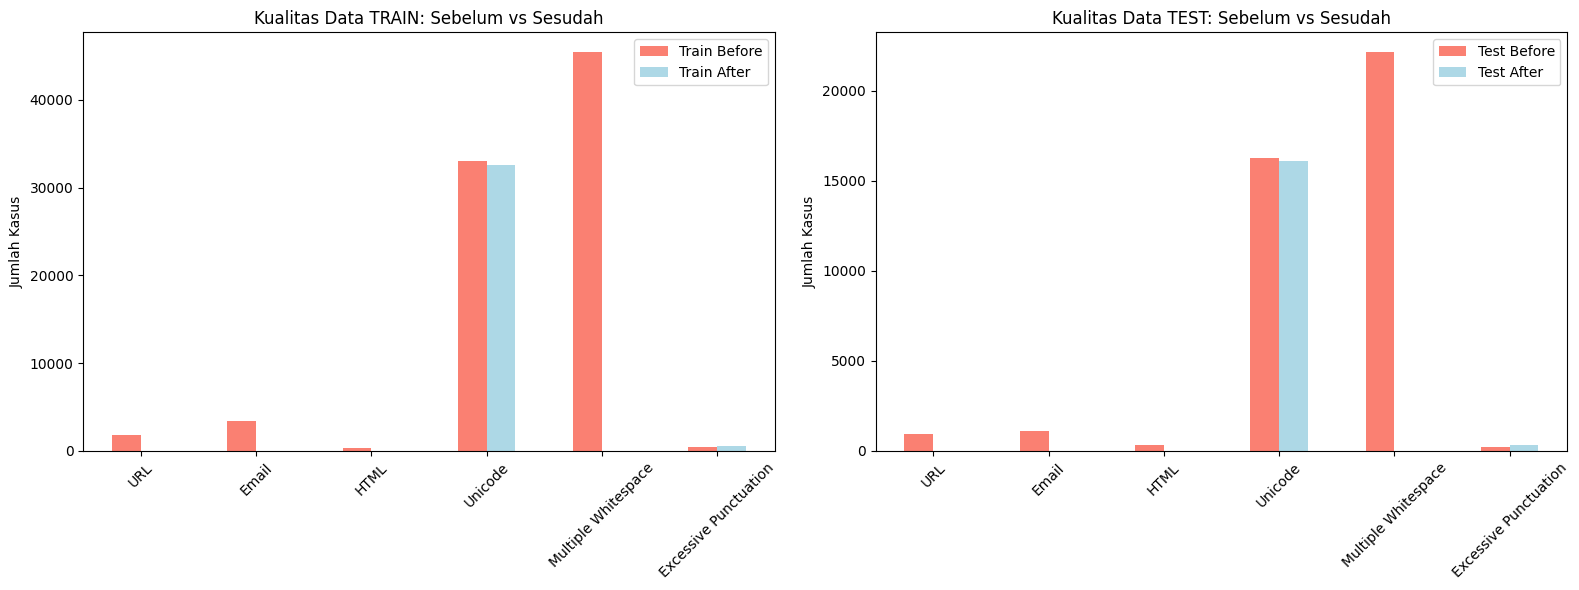

In [11]:
print("Memeriksa kualitas data TRAIN setelah preprocessing...")
train_qual_after = df_train_proc['articleBody'].apply(check_quality)
train_qual_after.columns = train_qual.columns

print("Memeriksa kualitas data TEST setelah preprocessing...")
test_qual_after = df_test_proc['articleBody'].apply(check_quality)
test_qual_after.columns = train_qual.columns

qual_after_df = pd.DataFrame({
    'Train After': train_qual_after.sum(),
    'Test After': test_qual_after.sum()
})

comparison_df = pd.concat([qual_before_df, qual_after_df], axis=1)
# Mengurutkan kolom agar lebih mudah dibaca
comparison_df = comparison_df[['Train Before', 'Train After', 'Test Before', 'Test After']]

display(comparison_df)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
comparison_df[['Train Before', 'Train After']].plot(kind='bar', ax=axes[0], color=['salmon', 'lightblue'])
axes[0].set_title('Kualitas Data TRAIN: Sebelum vs Sesudah')
axes[0].set_ylabel('Jumlah Kasus')
axes[0].tick_params(axis='x', rotation=45)

comparison_df[['Test Before', 'Test After']].plot(kind='bar', ax=axes[1], color=['salmon', 'lightblue'])
axes[1].set_title('Kualitas Data TEST: Sebelum vs Sesudah')
axes[1].set_ylabel('Jumlah Kasus')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 13 — Data Integrity Check

In [12]:
print("=== Validasi Integritas Data ===")

# Jumlah baris
assert len(df_train) == len(df_train_proc), "ERROR: Jumlah baris data train berubah!"
assert len(df_test) == len(df_test_proc), "ERROR: Jumlah baris data test berubah!"
print("✅ Jumlah baris train dan test tidak berubah.")

# Label stance (jika ada)
if 'Stance' in df_train.columns:
    assert df_train['Stance'].isna().sum() == df_train_proc['Stance'].isna().sum(), "ERROR: Terdapat label stance yang hilang!"
    print("✅ Label stance utuh.")

# Pengecekan teks kosong
train_empty_headline = (df_train_proc['Headline'] == "").sum()
train_empty_body = (df_train_proc['articleBody'] == "").sum()
test_empty_headline = (df_test_proc['Headline'] == "").sum()
test_empty_body = (df_test_proc['articleBody'] == "").sum()

assert train_empty_headline == 0, "ERROR: Terdapat Headline kosong di data Train!"
assert train_empty_body == 0, "ERROR: Terdapat Article Body kosong di data Train!"
assert test_empty_headline == 0, "ERROR: Terdapat Headline kosong di data Test!"
assert test_empty_body == 0, "ERROR: Terdapat Article Body kosong di data Test!"
print("✅ Tidak ada headline atau article body yang menjadi kosong akibat preprocessing.")

=== Validasi Integritas Data ===
✅ Jumlah baris train dan test tidak berubah.
✅ Label stance utuh.
✅ Tidak ada headline atau article body yang menjadi kosong akibat preprocessing.


## Section 14 — Example Comparison

In [13]:
print("=== Contoh Perbandingan Sebelum vs Sesudah Preprocessing ===")

# Ambil 10 sampel acak dari data train
sample_indices = df_train.sample(10, random_state=42).index

for i, idx in enumerate(sample_indices, 1):
    print(f"\n--- Sample {i} ---")
    print("[BEFORE CLEANING]")
    print(f"Headline: {df_train.loc[idx, 'Headline']}")
    print(f"Body: {df_train.loc[idx, 'articleBody'][:200]}...") # Dibatasi 200 karakter
    
    print("\n[AFTER CLEANING]")
    print(f"Headline: {df_train_proc.loc[idx, 'Headline']}")
    print(f"Body: {df_train_proc.loc[idx, 'articleBody'][:200]}...")
    print("-" * 80)

=== Contoh Perbandingan Sebelum vs Sesudah Preprocessing ===

--- Sample 1 ---
[BEFORE CLEANING]
Headline: Mum faces real-life Sophie's Choice – as she tries to sell her son to fund daughter's care
Body: (Mashable) Reports that Islamic State militants in Mosul have contracted Ebola swirled though Iraqi media sources on Wednesday. World Health Organization officials said they haven’t confirmed the case...

[AFTER CLEANING]
Headline: Mum faces real-life Sophie's Choice – as she tries to sell her son to fund daughter's care
Body: (Mashable) Reports that Islamic State militants in Mosul have contracted Ebola swirled though Iraqi media sources on Wednesday. World Health Organization officials said they haven’t confirmed the case...
--------------------------------------------------------------------------------

--- Sample 2 ---
[BEFORE CLEANING]
Headline: Dog Found Abandoned With Suitcase Filled With His Belongings
Body: Fox & Friends got very excited Thursday morning over rumors, which th

## Section 15 — Save Processed Dataset

In [14]:
output_dir = './data/processed/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Direktori {output_dir} berhasil dibuat.")

train_output_path = os.path.join(output_dir, 'train_processed.csv')
test_output_path = os.path.join(output_dir, 'test_processed.csv')

df_train_proc.to_csv(train_output_path, index=False)
df_test_proc.to_csv(test_output_path, index=False)

print("✅ Dataset berhasil disimpan!")
print(f"Train path: {train_output_path}")
print(f"Test path: {test_output_path}")

✅ Dataset berhasil disimpan!
Train path: ./data/processed/train_processed.csv
Test path: ./data/processed/test_processed.csv


## Section 16 — Final Summary

In [15]:
display(comparison_df)

,Train Before,Train After,Test Before,Test After
URL,1791,0,913,0
Email,3389,0,1082,0
HTML,284,0,304,0
Unicode,33002,32520,16250,16097
Multiple Whitespace,45417,0,22136,0
Excessive Punctuation,391,549,192,342


**Kesimpulan Preprocessing:**
- Proses pembersihan seperti konversi entitas URL dan Email berhasil direduksi seluruhnya (menjadi 0) karena telah ditangani dengan aman dengan *token replacing* `[URL]` dan `[EMAIL]`.
- Isu multi spasi (Multiple Whitespace) yang masif telah diperbaiki.
- Perbaikan tag HTML berhasil tanpa merusak kalimat di dalamnya berkat penggunaan BeautifulSoup.
- Karakter aneh non-ASCII / Unicode telah dinormalisasi menggunakan algoritma `NFKC` untuk memperbaiki variasi ekuivalen karakter Unicode ke bentuk dasarnya secara halus.
- Integritas relasi semantik, angka, tanda baca esensial, dan kapitalisasi tetap utuh, sehingga representasi yang masuk ke model Transformer akan tetap optimal.